# FitNova — Squat Dataset: Exploratory Data Analysis

Dataset: **Fitness-AQA** (Parmar et al., ECCV 2022), Squat labeled set — in-the-wild gym
video with expert error annotations. Two video errors:
**KFE** = knees travelling too far forward, **KIE** = knees caving inward.

This notebook characterizes the data before any modelling: split sizes, class balance,
error co-occurrence, clip properties, label intervals, and sample frames. All computed
directly from the official label/split JSONs + the clips.

In [1]:
import os, sys, json, time
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Locate project root + dataset.
_d = os.getcwd()
while _d != os.path.dirname(_d):
    if os.path.isdir(os.path.join(_d, "Fitness-AQA")) and os.path.isdir(os.path.join(_d, "docs")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
BASE = ("Fitness-AQA/Fitness-AQA_dataset_release-20260518T073812Z-3-001/"
        "Fitness-AQA_dataset_release/Squat/Labeled_Dataset")
VIDS = os.path.join(BASE, "videos_extracted", "videos")

kfe = json.load(open(os.path.join(BASE, "Labels/error_knees_forward.json")))
kie = json.load(open(os.path.join(BASE, "Labels/error_knees_inward.json")))
splits = {s: list(json.load(open(os.path.join(BASE, f"Splits/{s}_keys.json"))))
          for s in ["train", "val", "test"]}
all_clips = sorted(set(kfe) | set(kie))
print(f"labeled clips: {len(all_clips)}  |  splits: "
      + ", ".join(f"{s}={len(v)}" for s, v in splits.items()))

labeled clips: 1623  |  splits: train=1136, val=243, test=244


## 1. Official train / val / test splits
We use the dataset's official split JSONs verbatim — identical to Parmar et al., so our
F1 is directly comparable.

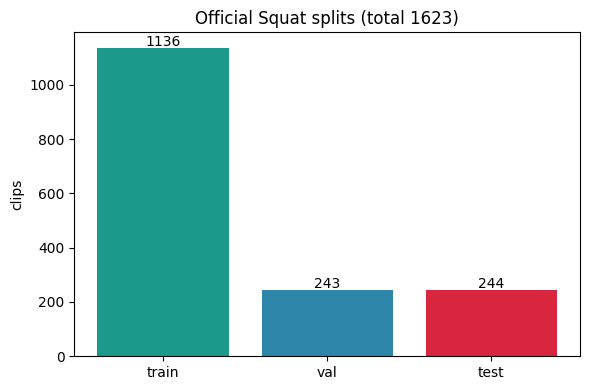

In [2]:
sizes = {s: len(v) for s, v in splits.items()}
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(sizes.keys(), sizes.values(), color=["#1B998B", "#2E86AB", "#D7263D"])
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 8, str(int(b.get_height())), ha="center")
ax.set_ylabel("clips"); ax.set_title(f"Official Squat splits (total {len(all_clips)})")
plt.tight_layout(); plt.show()

## 2. Class balance — the imbalance that drives the modelling
KFE is common (~68%); **KIE is rare (~14%)** — the hard class. This imbalance is why a
class-weighted loss (`BCEWithLogitsLoss(pos_weight=…)`) was used rather than plain BCE.

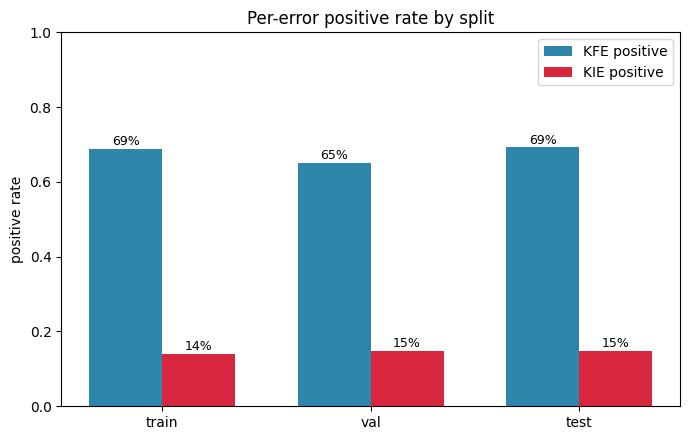

In [3]:
rows = []
for s in ["train", "val", "test"]:
    ks = splits[s]
    rows.append((s, sum(1 for c in ks if kfe.get(c)) / len(ks),
                    sum(1 for c in ks if kie.get(c)) / len(ks)))
labels = [r[0] for r in rows]
x = np.arange(len(labels)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, [r[1] for r in rows], w, label="KFE positive", color="#2E86AB")
ax.bar(x + w/2, [r[2] for r in rows], w, label="KIE positive", color="#D7263D")
for i, r in enumerate(rows):
    ax.text(i - w/2, r[1] + 0.01, f"{r[1]:.0%}", ha="center", fontsize=9)
    ax.text(i + w/2, r[2] + 0.01, f"{r[2]:.0%}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1)
ax.set_ylabel("positive rate"); ax.set_title("Per-error positive rate by split")
ax.legend(); plt.tight_layout(); plt.show()

## 3. Error co-occurrence
KIE and KFE overlap heavily — most knees-inward clips ALSO have knees-forward. This is
why the model uses a **single shared backbone with a joint 2-label head**, not two
independent models.

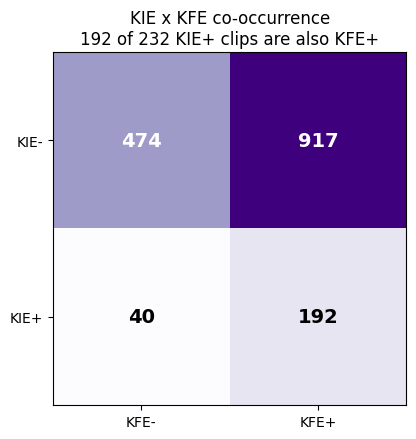

In [4]:
kie_pos = [c for c in all_clips if kie.get(c)]
both = sum(1 for c in kie_pos if kfe.get(c))
cm = np.array([
    [sum(1 for c in all_clips if not kie.get(c) and not kfe.get(c)),
     sum(1 for c in all_clips if not kie.get(c) and kfe.get(c))],
    [sum(1 for c in all_clips if kie.get(c) and not kfe.get(c)),
     both],
])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.imshow(cm, cmap="Purples")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center", fontsize=14, fontweight="bold",
            color="white" if v > cm.max()/2 else "black")
ax.set_xticks([0, 1]); ax.set_xticklabels(["KFE-", "KFE+"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["KIE-", "KIE+"])
ax.set_title(f"KIE x KFE co-occurrence\n{both} of {len(kie_pos)} KIE+ clips are also KFE+")
plt.tight_layout(); plt.show()

## 4. Clip properties (frame count, duration, fps, resolution)
Single-rep clips, ~3 s @ 30 fps, mixed resolutions & orientations (relevant later: the
in-the-wild variety is why home/portrait phone video is out-of-domain).

scanned 1623 clips in 11.6s


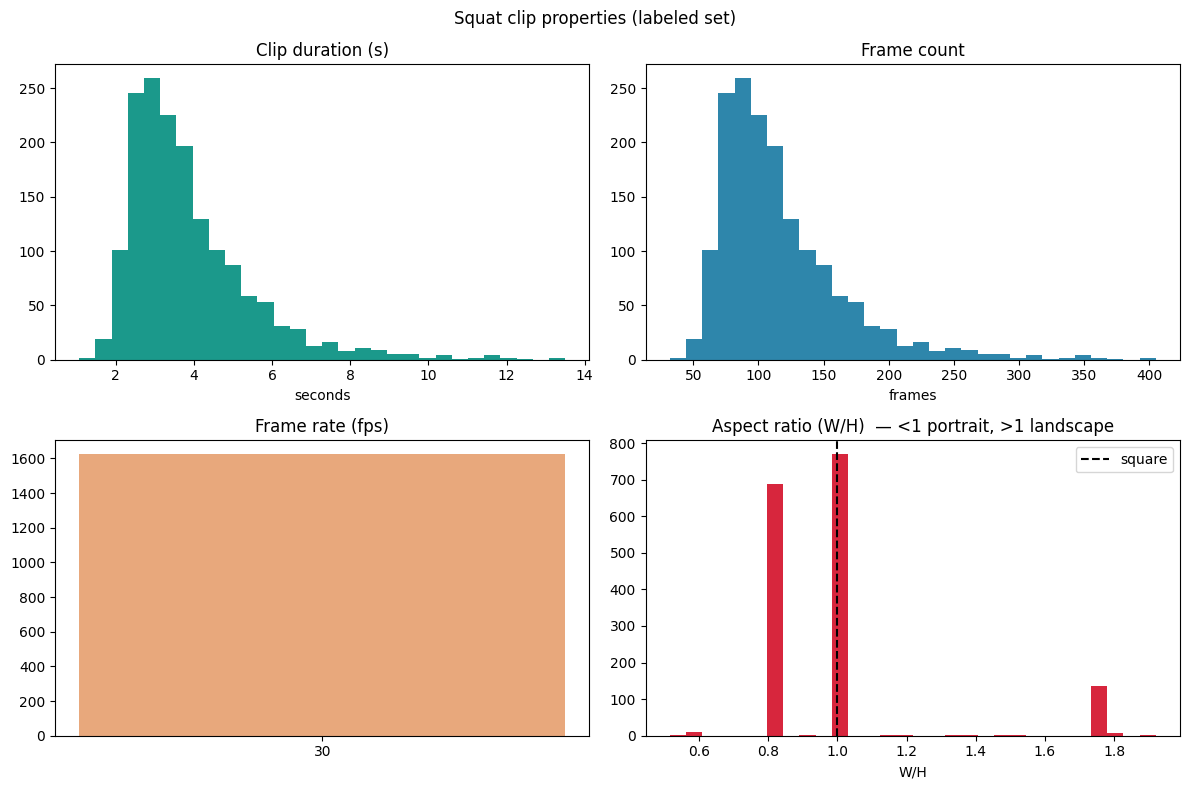

duration: median 3.5s | frames median 104 | landscape 9% / portrait 43%


In [5]:
t0 = time.time(); props = []
for c in all_clips:
    p = os.path.join(VIDS, f"{c}.mp4")
    if not os.path.exists(p):
        continue
    cap = cv2.VideoCapture(p)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); fps = cap.get(cv2.CAP_PROP_FPS)
    wdt = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); hgt = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    if n > 0 and fps > 0:
        props.append((n, n/fps, fps, wdt, hgt))
props = np.array(props)
print(f"scanned {len(props)} clips in {time.time()-t0:.1f}s")

fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs[0, 0].hist(props[:, 1], bins=30, color="#1B998B"); axs[0, 0].set_title("Clip duration (s)"); axs[0, 0].set_xlabel("seconds")
axs[0, 1].hist(props[:, 0], bins=30, color="#2E86AB"); axs[0, 1].set_title("Frame count"); axs[0, 1].set_xlabel("frames")
fps_vals, fps_cnt = np.unique(props[:, 2].round().astype(int), return_counts=True)
axs[1, 0].bar([str(v) for v in fps_vals], fps_cnt, color="#E8A87C"); axs[1, 0].set_title("Frame rate (fps)")
ar = props[:, 3] / props[:, 4]
axs[1, 1].hist(ar, bins=30, color="#D7263D"); axs[1, 1].axvline(1.0, color="k", ls="--", label="square")
axs[1, 1].set_title("Aspect ratio (W/H)  — <1 portrait, >1 landscape"); axs[1, 1].set_xlabel("W/H"); axs[1, 1].legend()
fig.suptitle("Squat clip properties (labeled set)", fontsize=12)
plt.tight_layout(); plt.show()
print(f"duration: median {np.median(props[:,1]):.1f}s | frames median {np.median(props[:,0]):.0f} | "
      f"landscape {100*(ar>1).mean():.0f}% / portrait {100*(ar<1).mean():.0f}%")

## 5. Label interval distributions (KFE)
Video errors carry `[start, end]` time intervals. Distribution of error durations and
where in the clip the error occurs.

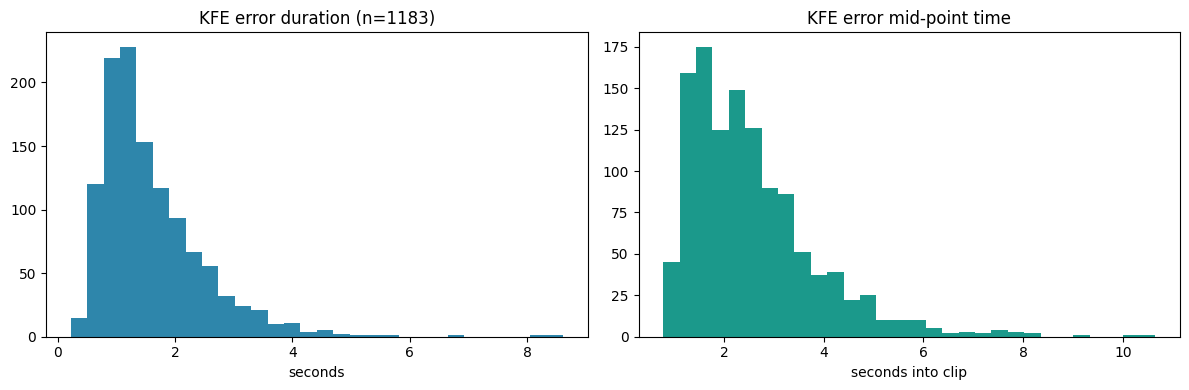

KFE intervals: 1183 | mean duration 1.59s


In [6]:
durs, mids = [], []
for c in all_clips:
    for iv in (kfe.get(c) or []):
        durs.append(iv[1] - iv[0]); mids.append((iv[0] + iv[1]) / 2)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(durs, bins=30, color="#2E86AB"); axs[0].set_title(f"KFE error duration (n={len(durs)})"); axs[0].set_xlabel("seconds")
axs[1].hist(mids, bins=30, color="#1B998B"); axs[1].set_title("KFE error mid-point time"); axs[1].set_xlabel("seconds into clip")
plt.tight_layout(); plt.show()
print(f"KFE intervals: {len(durs)} | mean duration {np.mean(durs):.2f}s")

## 6. Sample frames per class
Mid-clip (squat-bottom) frames — KFE positive, clean, and KIE positive examples.

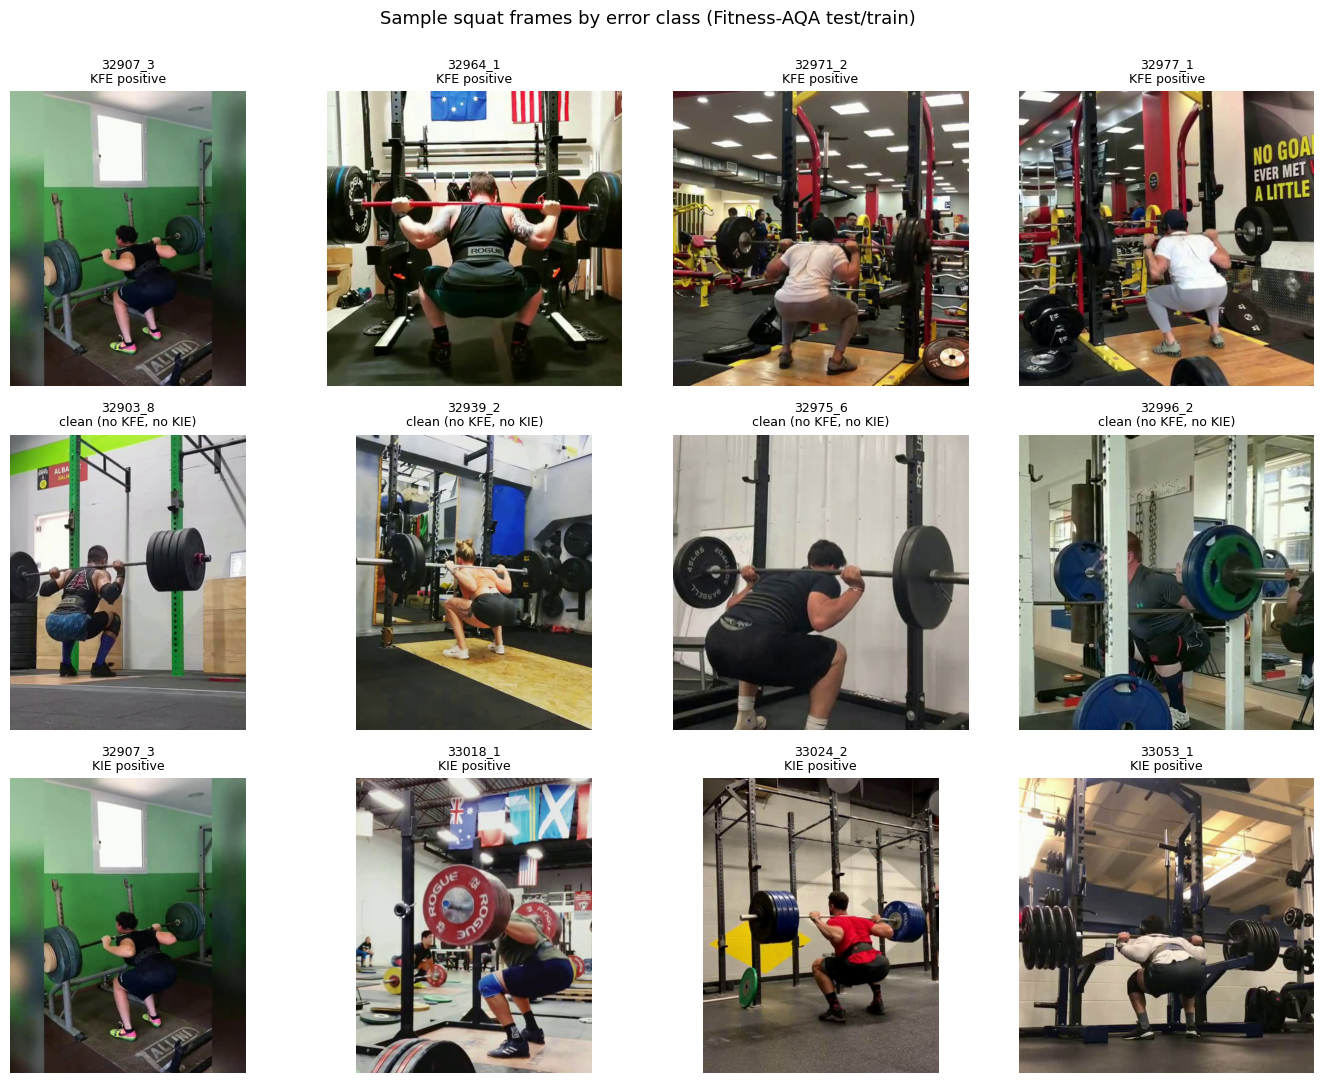

In [7]:
def mid_frame(cid):
    p = os.path.join(VIDS, f"{cid}.mp4")
    cap = cv2.VideoCapture(p); n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 1
    cap.set(cv2.CAP_PROP_POS_FRAMES, n // 2); ok, f = cap.read(); cap.release()
    return cv2.cvtColor(f, cv2.COLOR_BGR2RGB) if ok else None

cats = [
    ("KFE positive", [c for c in all_clips if kfe.get(c)][:4]),
    ("clean (no KFE, no KIE)", [c for c in all_clips if not kfe.get(c) and not kie.get(c)][:4]),
    ("KIE positive", [c for c in all_clips if kie.get(c)][:4]),
]
fig, axes = plt.subplots(len(cats), 4, figsize=(14, 11))
for r, (title, clips) in enumerate(cats):
    for cidx in range(4):
        ax = axes[r][cidx]; ax.axis("off")
        if cidx < len(clips):
            fr = mid_frame(clips[cidx])
            if fr is not None: ax.imshow(fr)
            ax.set_title(f"{clips[cidx]}\n{title}", fontsize=9)
fig.suptitle("Sample squat frames by error class (Fitness-AQA test/train)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

## Summary
- **1623 clips**, official splits 1136 / 243 / 244 (train/val/test).
- **Heavy imbalance:** KFE ~68% positive, **KIE ~14%** (rare, hard) → class-weighted loss.
- **Strong co-occurrence:** most KIE+ clips are also KFE+ → joint 2-label head over one backbone.
- Single-rep clips ~3 s @ 30 fps, mixed resolution/orientation (in-the-wild variety).

These observations shape the modelling pipeline: official splits, `pos_weight`
class-weighting, 32-frame/112² sampling, and the joint-head architecture.